# CMP 5006: Information Security - Homework 1
### Integrantes:

*   Juan Pablo Bautista
*   Daniela Salazar
*   Ryan de la Torre


## Topic: Foundations, Classical Ciphers, and Mathematical Underpinnings



### Section 1: Research - Historical & Advanced Classical Ciphers
Since we did not cover these in detail during lecture, research the following four topics to understand how they moved beyond simple substitution:



#### The Vigenère Cipher:
- Mechanism: Explain how the Vigenère Square (Tabula Recta) is used to encrypt a message using a keyword.
- Analysis: How does this polyalphabetic approach defend against basic frequency analysis?
- Breaking the Cipher: Briefly describe the Kasiski examination and how it determines keyword length.


**El Cifrado Vigenère**

La Tabula Recta es una tabla 26x26 donde cada fila tiene el alfabeto inglés desplazado (la fila A es ABC...Z, la B es BCD...ZA, y así). Para cifrar un mensaje con una palabra clave:  
1. Repito la clave hasta que tenga la misma longitud que el mensaje ejemplo: "ATAQUE" con clave "LLAVE" queda "LLAVELLAVE".  
2. Para cada letra del mensaje, busco la fila de la letra de la clave y la columna de la letra del mensaje plano. La letra donde se cruzan es la cifrada.  
Esto es lo mismo que hacer la fórmula: C_i = (P_i + K_i) mod 26 donde A=0, B=1... Z=25.  
Por ejemplo: "A" (0) + clave "L" (11) = 11 mod 26 = "L".  
(Cipher, n.d)  

Este cifrado es polialfabético, o sea que usa varios alfabetos al mismo tiempo . Como la clave se repite, cada letra del mensaje se cifra con un desplazamiento diferente. Esto hace que las frecuencias de las letras del idioma  se "mezclen" y no se vean claritas en el texto cifrado. El análisis de frecuencia básico funciona solo en cifrados monoalfabéticos como el César, donde todas las letras usan el mismo desplazamiento fijo. Aquí no, porque parece texto al azar.  
(Hammond, 2015)  

Para encontrar la longitud de la clave, Kasiski busca repeticiones de 3 o más letras iguales en el texto cifrado. Por ejemplo, si encuentras "XYZ" dos veces, mides la distancia en posiciones entre ellas. Esa distancia normalmente es múltiplo de la longitud de la clave (porque la clave se repite cíclicamente). Entonces calculas el MCD (máximo común divisor) de varias distancias y eso te da candidatos para la longitud de clave. Después divides el texto en columnas por esa longitud y haces análisis de frecuencia César en cada columna.  
(Gibson, n.d.)  

Referencias  
Cipher, C. (n.d.). Vigenère table & square learning tool. Caesarcipher.org. Retrieved February 25, 2026, from https://caesarcipher.org/ciphers/vigenere/table.

Gibson, T. (n.d.). 8.3. The kasiski test — MA/CS 4200 cryptography. Macs4200.org. Retrieved February 25, 2026, from https://macs4200.org/chapters/08/3/kasiski-test.

Hammond, J. (2015, April 24). Encryption 101: The Vigenère cipher. Egress.com. https://www.egress.com/blog/email-encryption/encryption-101-the-vigenere-cipher

#### The Hill Cipher:
- Mathematical Basis: This cipher is based on linear algebra. Explain how a plaintext block is converted into a vector and multiplied by a key matrix.
- Requirements: What specific mathematical requirements must the key matrix meet to ensure a message can be decrypted?


**El cifrado Hill**

Utiliza álgebra lineal para transformar bloques de texto plano en cifrado mediante operaciones matriciales modulares.
A continuación, profundizo en cada aspecto con mayor detalle matemático y ejemplos paso a paso(Jaouadi, 2025).

El proceso comienza convirtiendo letras del texto plano en números: A=0, B=1, ..., Z=25.
Un bloque de n letras forma un vector columna P de dimensión n x 1.

- Conversión y multiplicación: Para una matriz clave K de n x n, el texto cifrado es C = (K x P) mod 26,
donde cada componente de C se toma módulo 26 y se convierte de vuelta a letras.

Ejemplo paso a paso (matriz 2x2):
1. Texto "HI" → P = [7]
                  [8]  (H=7, I=8).
2. Matriz clave K = [3  3]
                    [2  5].
3. Multiplicación: [3  3] x [7] = [3*7 + 3*8] = [21+24] = [45 ]
                  [2  5]   [8]   [2*7 + 5*8]   [14+40]   [54 ]
4. Módulo 26: [45 mod 26] = [19] → "T C" (T=19, C=2).
              [54 mod 26]   [2 ]

Esto se repite para bloques subsiguientes, agregando relleno si es necesario (ej. 'X' para longitudes no múltiplos de n).

Para que el cifrado sea invertible (descriptable de forma única), K debe tener una inversa modular módulo 26:
K^(-1) tal que K x K^(-1) ≡ I mod 26, donde I es la matriz identidad.

- Requisitos específicos:
  1. Cuadrada y no singular: det(K)not≡ 0 mod 26.
  2. Determinante coprimo con 26: gcd(det(K), 26) = 1.
     Como 26=2×13, det(K) no debe ser divisible por 2 ni por 13
     (posibles valores válidos: 1,3,5,7,9,11,15,17,19,21,23,25).
  3. Elementos enteros módulo 26: Todos los entradas de K son enteros en {0,1,...,25}.

- Cálculo de la inversa:
  1. Calcula det(K).
  2. Encuentra d^(-1) tal que d x d^(-1) ≡ 1 mod 26 (usa algoritmo extendido de Euclides).
  3. Ajusta la matriz adjunta: K^(-1) = d^(-1) x adj(K) mod 26.

Ejemplo: Para K anterior, det(K) = 3*5 - 3*2 = 15-6=9, gcd(9,26)=1.
Inversa existe: 9^(-1) mod 26 = 3 (pues 9×3=27≡1 mod 26).

Si no se cumple, múltiples textos planos mapearían al mismo cifrado, haciendo imposible la recuperación única.

Se invierte con P = (K^(-1) x C) mod 26.

Ejemplo completando el anterior:
- C = [19]
      [2 ].
- Adjunta de K: [ 5 -3] mod 26 = [ 5 23]
                [-2  3]         [-24  3] (nota: -2 mod 26 = 24, -3 mod 26 = 23)
- K^(-1) = 3 x [ 5 23] mod 26 = [15 16]
              [-24  3]         [20  9]
- K^(-1) x C = [15*19 + 16*2] mod 26 = [285 + 32] mod 26 = [317 mod 26] = [7 ]
               [20*19 +  9*2]         [380 + 18]         [398 mod 26]   [8 ] → "HI".


Referencias:
Jaouadi, M. H. (2025, July 5). The Hill cipher: Linear algebra meets cryptography. 0xHabib. https://www.0xhabib.tech/posts/hill-cipher-cryptography.

#### The Playfair Cipher:
- Mechanism: Explain the **process** of creating the $5 \times 5$ grid and the specific rules for encrypting a digraph (pair of letters).
- Historical Context: Research its use by British forces in WWI and WWII. Why was it considered "field-ready" compared to more complex systems?


**The Playfair**

¿En qué consiste el cifrado Playfair?
El cifrado Playfair es un sistema digrámico, es decir, cifra el mensaje en pares de letras en lugar de procesarlas individualmente. Fue inventado por Charles Wheatstone y difundido por Lord Playfair.

Se elige una clave
1. Se escribe la palabra clave sin repetir letras.
Ejemplo del texto: info
2. Se insertan sus letras en la cuadrícula
Las letras de la clave se colocan en la tabla de izquierda a derecha y de arriba abajo.
3. Se completa con el resto del alfabeto
Se añaden las letras del alfabeto que no aparecieron en la clave.


La I y la J se combinan en la misma casilla.
La Ñ se sustituye por la N.
El conjunto total debe ser de 25 casillas.

i n f o a
b c d e g
h k l m p
q r s t u
v w x y z

Reglas específicas para cifrar un dígrafo
El PDF establece cinco reglas para transformar los pares de letras:

1. Misma fila
Si ambas letras están en la misma fila, cada una se sustituye por la letra que está a su derecha.
Si una letra es la última de la fila, se reemplaza por la primera de esa misma fila.

2. Misma columna
Si ambas letras están en la misma columna, se sustituye cada una por la que está debajo de ella.
Si está en la última fila, se sustituye por la primera de la misma columna.

3. Rectángulo
Si las letras están en filas y columnas diferentes, se forma un rectángulo imaginario con ellas.
Cada letra se sustituye por la que se encuentra en su misma fila, pero en la columna de la otra letra.
(Es decir, se intercambian las columnas.)

4. Letras repetidas en un mismo par
Si un par tiene dos letras iguales, se inserta una X entre ellas.
Ejemplo: ll → lx

5. Longitud impar
Si el mensaje tiene un número impar de caracteres, se añade una X para completar el último par.


## Contexto histórico
Las fuerzas británicas lo adoptaron en la Primera Guerra Mundial para comunicaciones de campo y continuaron en la Segunda, donde también usaron variantes como el doble Playfair.
Se consideraba "listo para el campo" por requerir solo lápiz, papel y minutos para cifrar/descifrar, a diferencia de máquinas complejas como Enigma que necesitaban equipo especializado y eran vulnerables a fallos mecánicos(Rivera, 2014).



Romero, A. E. (2019). Arqueología informática: Implementación de sistemas clásicos de cifrado en Scratch (Trabajo Fin de Grado). Universitat Politècnica de València.
Rivera, K. (2014, May 7). Client challenge. Scribd.com. https://es.scribd.com/doc/222766944/Playfair.

#### The Enigma Machine:
- Rotor Logic: Explain the concept of the rotors and how they caused the substitution alphabet to change with every single keystroke.
- The Reflector: What was the purpose of the reflector in the Enigma's circuitry, and why did it mean a letter could never be encrypted as itself?
- The Plugboard: How did the plugboard (Steckerbrett) exponentially increase the number of possible configurations?

**Máquina Enigma**

Fue una máquina usada por los alemanes para encriptar y asegurar la difusión de sus mensajes durante la segunda guerra mundial.
Lógica de los Rotores
En la máquina Enigma, los rotores eran discos con veintiséis conectores en cada lado, unidos por un cableado interno distinto para cada rotor. Este cableado hacía que, al ingresar una corriente eléctrica desde una tecla, la señal saliera transformada en otra letra. Lo esencial era que estos rotores no eran estáticos: cada vez que se presionaba una tecla, el rotor situado más a la derecha avanzaba una posición. Luego de que este rotor completaba una vuelta completa de veintiséis pasos, hacía avanzar al siguiente rotor. Este movimiento constante aseguraba que la trayectoria eléctrica cambiara cada vez que se aplastaba una tecla, produciendo un alfabeto de sustitución diferente cada vez. Por eso, incluso si se presionaba repetidamente la misma letra, el resultado jamás era igual, ya que la posición de los rotores y, por lo tanto, la ruta interna del circuito, siempre cambia. La sustitución era dinámica e impredecible, lo que hacía que la Enigma generara un cifrado enormemente difícil de atacar mediante métodos clásicos como el análisis de frecuencia.

El Reflector
El reflector era un componente fijo situado al final del conjunto de rotores. Su función era devolver la corriente eléctrica hacia atrás a través de los rotores, pero nunca por el mismo camino por el que había entrado. En otras palabras, cuando la señal llegaba al reflector, este la redirigía y la obligaba a atravesar nuevamente los rotores, aunque siguiendo una ruta completamente distinta. Este mecanismo tenía como consecuencia natural duplicar la complejidad del cifrado, ya que la señal realizaba un recorrido de ida y vuelta, multiplicando la cantidad de posibles transformaciones. Además, debido a la forma en que el reflector reenviaba la corriente, nunca permitía que la señal regresara exactamente por el mismo cableado inicial. Esto significaba que una letra jamás podía cifrarse como sí misma, ya que si la corriente entraba por la ruta correspondiente a la letra “A”, el retorno desde el reflector siempre se redirigía hacia un conector diferente. Por este motivo, en la Enigma ninguna letra podía aparecer como resultado de sí misma, algo que, aunque parecía dar más seguridad, terminó convirtiéndose en una pista clave para descifrar.

El Plugboard
El Plugboard estaba ubicado en la parte frontal de la máquina. Este era un panel que permitía conectar pares de letras mediante cables físicos. Estas conexiones realizaban intercambios antes de que la corriente ingresara al primer rotor, añadiendo así una capa adicional de sustitución al proceso de cifrado. En la práctica, esto significaba que si se conectaban letras como A y G, cada vez que se pulsara la letra A, la máquina trataría esa entrada como si fuera una G, y viceversa. Por lo general, se conectaban seis pares de letras, aunque podían ser más, y cada una de estas conexiones incrementaba drásticamente el número de posibles configuraciones. El documento señala que solo el Steckerbrett aportaba más de cien mil millones de combinaciones posibles, cifra que por sí sola superaba cualquier intento razonable de fuerza bruta para la época. Esta enorme cantidad de permutaciones añadida antes y después del proceso de los rotores hacía que la Enigma fuera un sistema de cifrado extremadamente complejo y aparentemente impenetrable para los medios técnicos de su tiempo.


Referencia:
Barro Ordovás, A. (2017). La clave Enigma. Revista General de Marina, (2), 233–247.
https://armada.defensa.gob.es/archivo/rgm/2017/02/cap03.pdf

### Section 2: Mathematical Foundations
Show all your work for the following problems based on our class materials.




1. Modular Arithmetic: Find $x$ for the following:
    - $x \equiv 457 \pmod{13}$
    - $x \equiv -25 \pmod{7}$


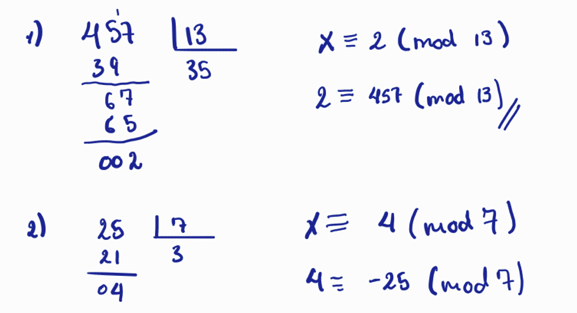

2. The Euclidean Algorithm:
    - Calculate $\gcd(1160, 480)$ using the Euclidean Algorithm.
    - Use the Extended Euclidean Algorithm to find $x, y$ such that $1160x + 480y = \gcd(1160, 480)$.


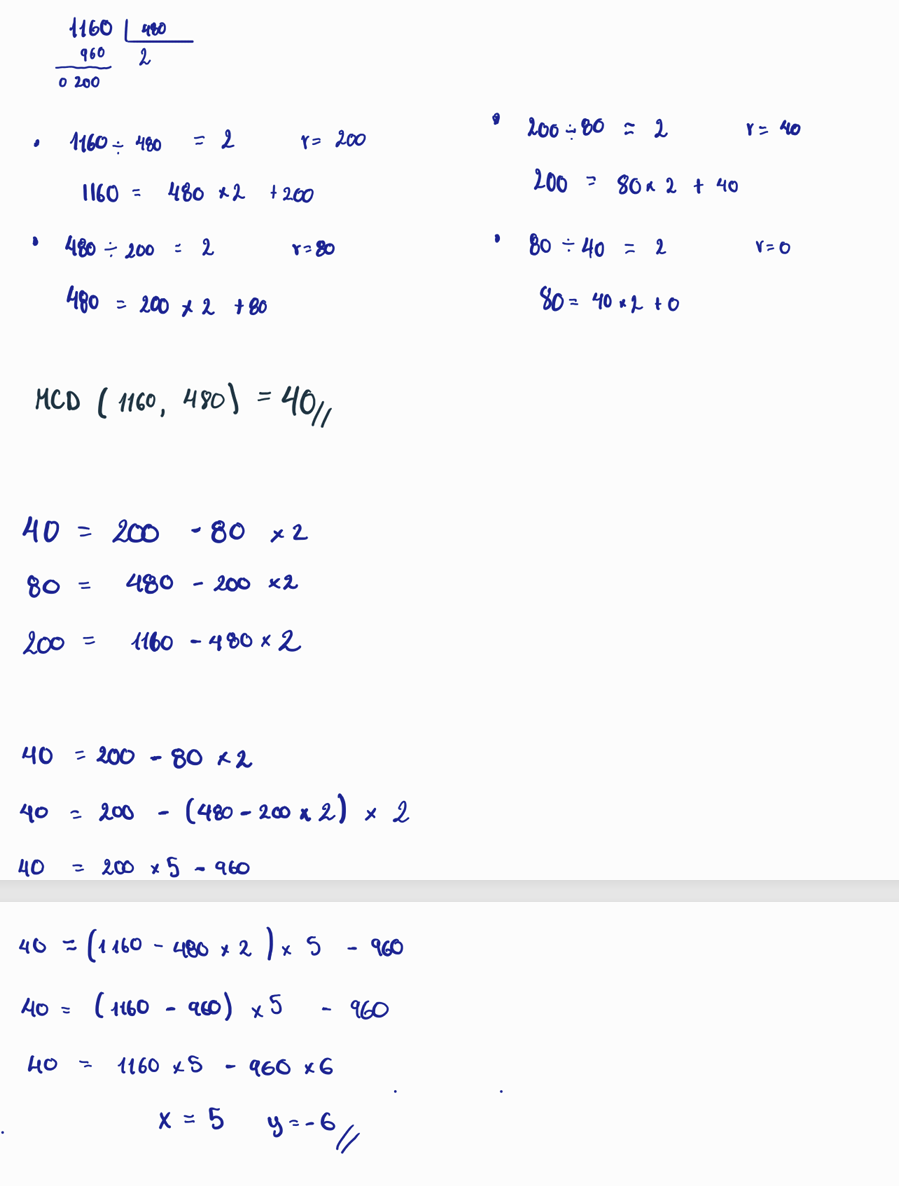

3. Euler’s Totient Function:
    - Calculate $\phi(21)$ and $\phi(17)$.
    - Calculate $\phi(360)$ using prime factorization.


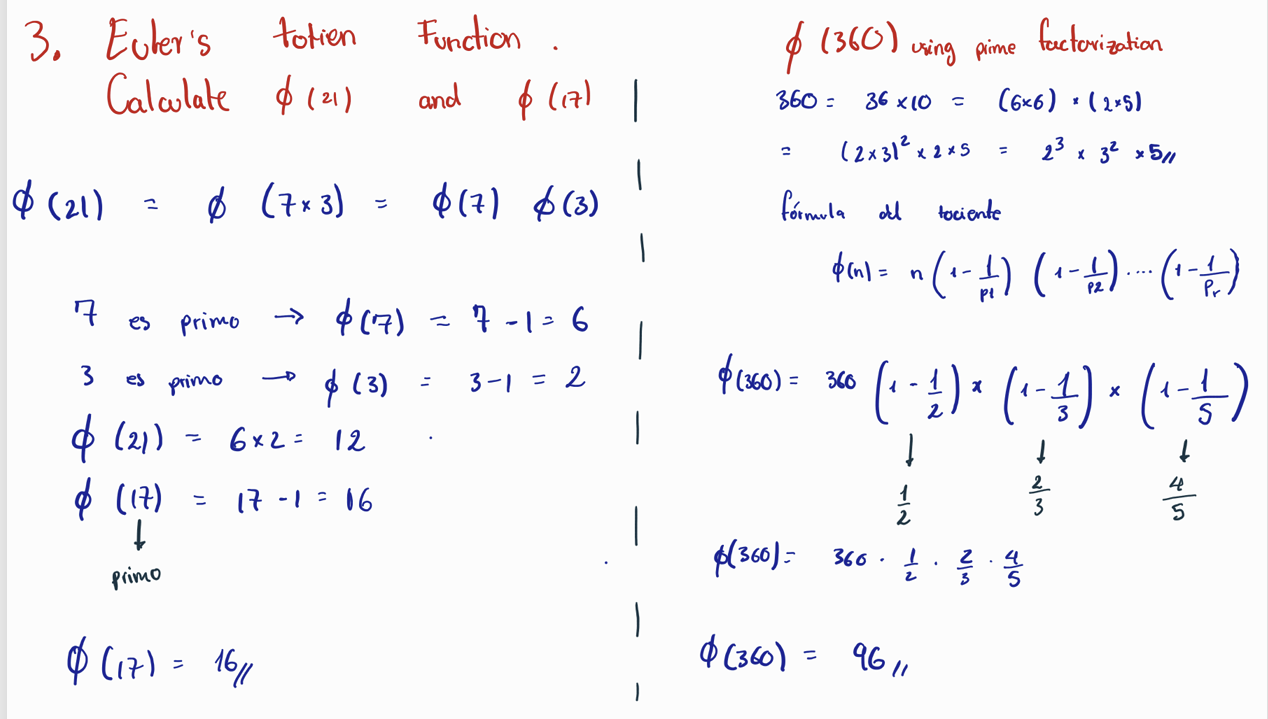

4. Information Theory: A source produces $\{A, B, C, D\}$ with probabilities $P(A)=1/2$, $P(B)=1/4$, $P(C)=1/8$, and $P(D)=1/8$.
    - Calculate the Shannon Entropy $H(X)$.


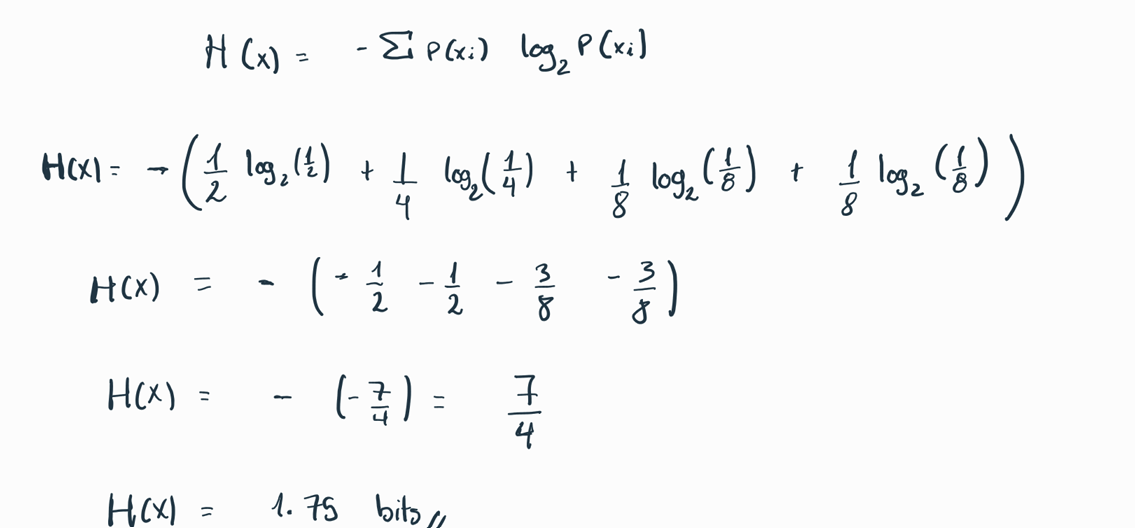

5. Bayes' Theorem: An Intrusion Detection System (IDS) is designed to flag a "Brute Force" attack.
    - The probability of an actual attack is $P(A) = 0.001$.
    - If there is an attack, the IDS correctly flags it with a probability of $0.99$ (True Positive).
    - If there is no attack, the IDS incorrectly flags it with a probability of $0.01$ (False Positive).
    - Question: If the IDS flags an event, what is the probability that an actual attack is occurring?

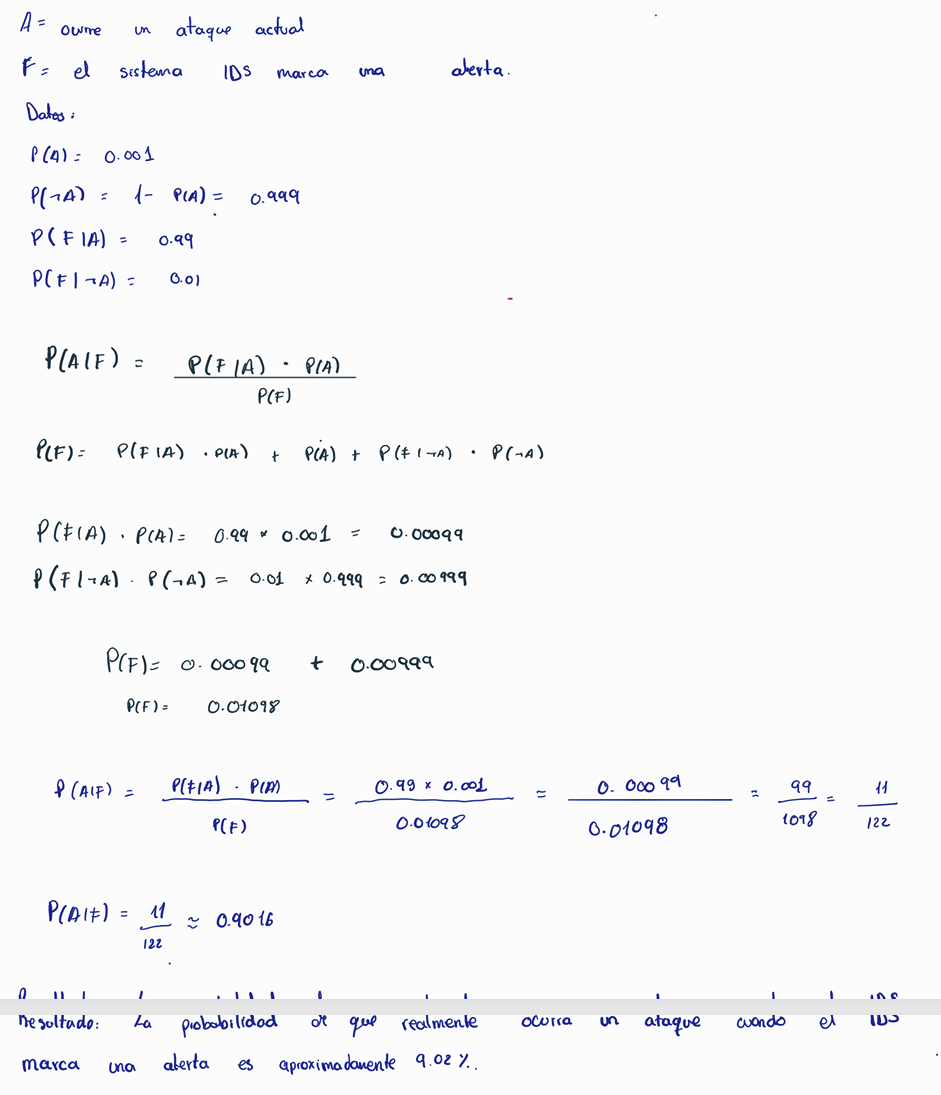

### Section 3: PicoCTF
Complete the assignment in PicoCTF platform.
- Submit your Python scripts and the flags.
- For eaach problem you will attempt two different methods to solve.

**Vigenere**

In [ ]:
ciphertext = "rgnoDVD{O0NU_WQ3_G1G3O3T3_A1AH3S_cc82272b}"

Solucion 1

In [ ]:
def vigenere_decrypt(ciphertext: str, key: str) -> str:
    A = ord('A')
    key = key.upper()
    out = []
    j = 0

    for ch in ciphertext:
        if ch.isalpha():
            base = ord('A') if ch.isupper() else ord('a')
            c = ord(ch) - base
            k = ord(key[j % len(key)]) - A
            p = (c - k) % 26
            out.append(chr(p + base))
            j += 1
        else:
            out.append(ch)

    return ''.join(out)
key = "CYLAB"
print(vigenere_decrypt(ciphertext, key))


picoCTF{D0NT_US3_V1G3N3R3_C1PH3R_ae82272q}


Solucion 2

In [ ]:
import itertools
import string


def vigenere_decrypt(ciphertext, key):
    result = ""
    key_index = 0
    for ch in ciphertext:
        if ch.isalpha():
            shift = ord(key[key_index % len(key)].upper()) - ord('A')
            base = ord('A') if ch.isupper() else ord('a')
            result += chr((ord(ch) - base - shift) % 26 + base)
            key_index += 1
        else:
            result += ch
    return result

for key_tuple in itertools.product(string.ascii_uppercase, repeat=5):
    key = ''.join(key_tuple)
    decrypted = vigenere_decrypt(ciphertext, key)
    if "picoCTF{" in decrypted:
        print("Key Found:", key)
        print( decrypted)
        break


Key Found: CYLAB
picoCTF{D0NT_US3_V1G3N3R3_C1PH3R_ae82272q}


**substitution2**

Esta solución es a partir de un análisis de frecuencia a mano:


Sustitución conocida

Ciphertext	s	x	z	q	Z	N	V

Plaintext	p	i	c	o	C	T	F


Reglas de sustitución

s → p

x → i

z → c

q → o

Z → C (mayúscula, misma regla)

N → T

V → F

Frecuencia de letras en inglés

| Num | Letra | Frecuencia |
|-----|--------|------------|
| 1   | e      | 12.7% |
| 2   | t      | 9.1%  |
| 3   | a      | 8.2%  |
| 4   | o      | 7.5%  ← ya se sabe: q → o |
| 5   | i      | 7.0%  ← ya se sabe: x → i |
| 6   | n      | 6.7%  |
| 7   | s      | 6.3%  ← ya se sabe: s → p |
| 8   | h      | 6.1%  |
| 9   | r      | 6.0%  |
| 10  | d      | 4.3%  |
| 11  | l      | 4.0%  |
| 12  | c      | 2.8%  |
| 13  | u      | 2.8%  |
| 14  | m      | 2.4%  |
| 15  | w      | 2.4%  |
| 16  | f      | 2.2%  |
| 17  | g      | 2.0%  |
| 18  | y      | 2.0%  |
| 19  | p      | 1.9%  |
| 20  | b      | 1.5%  |

Frecuencia observada en el texto cifrado

f → ~110 veces → posible e

n → ~95 veces → posible t

e → ~65 veces → posible s

t → ~60 veces → posible a

x → ~55 veces → i (confirmado)

q → ~55 veces → o (confirmado)

l → ~50 veces → posible n

a → ~45 veces → posible h

y → ~40 veces → posible r


Trigramas más comunes en inglés

| Rango | Grupo | Frecuencia |
|--------|--------|------------|
| 1      | the    | 3.508% |
| 2      | and    | 1.593% |
| 3      | ing    | 1.147% |
| 4      | ion    | 0.797% |
| 5      | ent    | 0.765% |
| 6      | tio    | 0.618% |
| 7      | for    | 0.557% |
| 8      | nde    | 0.530% |
| 9      | has    | 0.516% |
| 10     | nce    | 0.490% |


Análisis clave

naf aparece 28 veces

Coincide casi exactamente con frecuencia esperada de "the"

Conclusión:
naf = the
n → t
a → h
f → e


Segundo trigrama más frecuente

tlb aparece 11 veces

Coincide con frecuencia esperada de "and"

Conclusión:
tlb = and
t → a
l → n
b → d

Bigramas importantes

Los más comunes en inglés:

- th
- he
- in
- er
- an
- nd

Verificación:

na → th

af → he

Confirmado cientos de veces en el texto.

 ### Deducciones adicionales

De "computer"

zqgswnfy → computer

g → m

w → u

De "competition"

zqgsfnxnxql → competition

l → n

De "highschool"


axraezaqqp → highschool

r → g

p → l

e → s

De "checklist"

zafzcpxen → checklist

c → k

De "pique"

sxiwfnafxy → pique

i → q

De "we believe"

mfkfpxfuf → webelieve

m → w

k → b


Tabla final de sustitución

| Cifrado | Plano | Cifrado | Plano | Cifrado | Plano |
|----------|--------|----------|--------|----------|--------|
| a | h | j | — | s | p |
| b | d | k | b | t | a |
| c | k | l | n | u | v |
| d | — | m | w | v | f |
| e | s | n | t | w | u |
| f | e | o | x | x | i |
| g | m | p | l | y | r |
| h | y | q | o | z | c |
| i | q | r | g |  |  |


In [ ]:
ciphertext = """
nafyffoxenefufytpqnafymfppfentkpxeafbaxraezaqqpzqgswnfyefzwyxnhzqgsfnxnxqlexlzpwbxlrzhkfystnyxqntlbwezhkfyzatppflrfnafefzqgsfnxnxqlevqzwesyxgtyxphqlehenfgetbgxlxenytnxqlvwlbtgflntpemaxzatyfufyhwefvwptlbgtycfntkpfecxppeaqmfufymfkfpxfufnafsyqsfyswysqefqvtaxraezaqqpzqgswnfyefzwyxnhzqgsfnxnxqlxelqnqlphnqnftzautpwtkpfecxppekwntpeqnqrfnenwbflnexlnfyfenfbxltlbfozxnfbtkqwnzqgswnfyezxflzfbfvflexufzqgsfnxnxqletyfqvnflptkqyxqwetvvtxyetlbzqgfbqmlnqywllxlrzafzcpxenetlbfofzwnxlrzqlvxrezyxsneqvvflefqlnafqnafyatlbxeaftuxphvqzwefbqlfospqytnxqltlbxgsyquxetnxqltlbqvnflatefpfgflneqvspthmfkfpxfuftzqgsfnxnxqlnqwzaxlrqlnafqvvflexuffpfgflneqvzqgswnfyefzwyxnhxenafyfvqyftkfnnfyufaxzpfvqynfzafutlrfpxegnqenwbflnexltgfyxztlaxraezaqqpevwynafymfkfpxfufnatntlwlbfyentlbxlrqvqvvflexufnfzalxiwfexefeeflnxtpvqygqwlnxlrtlfvvfznxufbfvfleftlbnatnnafnqqpetlbzqlvxrwytnxqlvqzweflzqwlnfyfbxlbfvflexufzqgsfnxnxqlebqfelqnpftbenwbflnenqclqmnafxyflfghtefvvfznxufphtenftzaxlrnafgnqtznxufphnaxlcpxcftltnntzcfysxzqznvxetlqvvflexufphqyxflnfbaxraezaqqpzqgswnfyefzwyxnhzqgsfnxnxqlnatneffcenqrflfytnfxlnfyfenxlzqgswnfyezxflzftgqlraxraezaqqpfyenftzaxlrnafgflqwratkqwnzqgswnfyefzwyxnhnqsxiwfnafxyzwyxqexnhgqnxutnxlrnafgnqfospqyfqlnafxyqmltlbfltkpxlrnafgnqkfnnfybfvflbnafxygtzaxlfenafvptrxesxzqZNV{L6Y4G_4L41H515_15_73B10W5_8F1KV808}
""".upper()

Solucion 1

In [ ]:
import re

cipher_to_plain = {
    'T': 'A',
    'K': 'B',
    'Z': 'C',
    'B': 'D',
    'F': 'E',
    'V': 'F',
    'R': 'G',
    'A': 'H',
    'X': 'I',
    'C': 'K',
    'P': 'L',
    'G': 'M',
    'L': 'N',
    'Q': 'O',
    'S': 'P',
    'I': 'Q',
    'Y': 'R',
    'E': 'S',
    'N': 'T',
    'W': 'U',
    'U': 'V',
    'M': 'W',
    'O': 'X',
    'H': 'Y'
}

def decrypt(text):
    result = ""
    for char in text:
        if char in cipher_to_plain:
            result += cipher_to_plain[char]
        else:
            result += char
    return result

decrypted = decrypt(ciphertext)

print("="*60)
print("TEXTO DESCIFRADO COMPLETO:")
print("="*60)
print(decrypted)

flag = re.search(r"picoCTF\{.*?\}", decrypted, re.IGNORECASE)

print("\n" + "="*60)
if flag:
    print("FLAG ENCONTRADA:")
    print(flag.group())
else:
    print("No se encontró la flag automáticamente.")
    print("Revisa el texto descifrado arriba.")
print("="*60)

TEXTO DESCIFRADO COMPLETO:

THEREEXISTSEVERALOTHERWELLESTABLISHEDHIGHSCHOOLCOMPUTERSECURITYCOMPETITIONSINCLUDINGCYBERPATRIOTANDUSCYBERCHALLENGETHESECOMPETITIONSFOCUSPRIMARILYONSYSTEMSADMINISTRATIONFUNDAMENTALSWHICHAREVERYUSEFULANDMARKETABLESKILLSHOWEVERWEBELIEVETHEPROPERPURPOSEOFAHIGHSCHOOLCOMPUTERSECURITYCOMPETITIONISNOTONLYTOTEACHVALUABLESKILLSBUTALSOTOGETSTUDENTSINTERESTEDINANDEXCITEDABOUTCOMPUTERSCIENCEDEFENSIVECOMPETITIONSAREOFTENLABORIOUSAFFAIRSANDCOMEDOWNTORUNNINGCHECKLISTSANDEXECUTINGCONFIGSCRIPTSOFFENSEONTHEOTHERHANDISHEAVILYFOCUSEDONEXPLORATIONANDIMPROVISATIONANDOFTENHASELEMENTSOFPLAYWEBELIEVEACOMPETITIONTOUCHINGONTHEOFFENSIVEELEMENTSOFCOMPUTERSECURITYISTHEREFOREABETTERVEHICLEFORTECHEVANGELISMTOSTUDENTSINAMERICANHIGHSCHOOLSFURTHERWEBELIEVETHATANUNDERSTANDINGOFOFFENSIVETECHNIQUESISESSENTIALFORMOUNTINGANEFFECTIVEDEFENSEANDTHATTHETOOLSANDCONFIGURATIONFOCUSENCOUNTEREDINDEFENSIVECOMPETITIONSDOESNOTLEADSTUDENTSTOKNOWTHEIRENEMYASEFFECTIVELYASTEACHINGTHEMTOACTIVELYTHINKLIKEANATTACKER

Solucion 2

In [ ]:
import re
import math
import random
from collections import Counter, defaultdict


CIPHER_TEXT = """nafyffoxenefufytpqnafymfppfentkpxeafbaxraezaqqpzqgswnfyefzwyxnhzqgsfnxnxqlexlzpwbxlrzhkfystnyxqltlbwezhkfyzatppflrfnafefzqgsfnxnxqlevqzwesyxgtyxphqlehenfgetbgxlxenytnxqlvwlbtgflntpemaxzatyfufyhwefvwptlbgtycfntkpfecxppetqmfufymfkfpxfufnafsyqsfyswysqefqvtaxraezaqqpzqgswnfyefzwyxnhzqgsfnxnxqlxelqnqlphnqnftzautpwtkpfecxppekwntpeqnqrfnenwbflnexlnfyfenfbxltlbfozxnfbtkqwnzqgswnfyezxflzfbfvflexufzqgsfnxnxqletyfqvnflptkqyxqwetvvtxyetlbzqgfbqmlnqywllxlrzafzcpxenetlbfofzwnxlrzqlvxrezyxsneqvvflefqlnafqnafyatlbxeaftuxphvqzwefbqlfospqytnxqltlbxgsyquxetnxqltlbqvnflatefpfgflneqvspthmfkfpxfuftzqgsfnxnxqlnqwzaxlrqlnafqvvflexuffpfgflneqvzqgswnfyefzwyxnhxenafyfvqyftkfnnfyufaxzpfvqynfzafutlrfpxegnqenwbflnexltgfyxztlaxraezaqqpevwynafymfkfpxfufnatntlwlbfyentlbxlrqvqvvflexufnfzalxiwfexefeeflnxtpvqygqwlnxlrtlfvvfznxufbfvfleftlbnatnnafnqqpetlbzqlvxrwytnxqlvqzwefflzqwlnfyfbxlbfvflexufzqgsfnxnxqlebqfelqnpftbenwbflnenqclqmnafxyflfghtefvvfznxufphtenftzaxlrnafgnqtznxufphnaxlcpxcftltnntzcfysxzqznvxetlqvvflexufphqyxflnfbaxraezaqqpzqgswnfyefzwyxnhzqgsfnxnxqlnatneffcenqrflfytnfxlnfyfenxlzqgswnfyezxflzftgqlraxraezaqqpfyenftzaxlrnafgflqwratkqwnzqgswnfyefzwyxnhnqsxiwfnafxyzwyxqexnhgqnxutnxlrnafgnqfospqyfqlnafxyqmltlbfltkpxlrnafgnqkfnnfybfvflbnafxygtzaxlfenafvptrxesxzqZNV{L6Y4G_4L41H515_15_73B10W5_8F1KV808}"""


CIPHER_HINT = "sxzqZNV"
PLAIN_HINT  = "picoCTF"

_BG = {
    "th":0.0271,"he":0.0233,"in":0.0203,"er":0.0178,"an":0.0161,
    "re":0.0141,"on":0.0132,"at":0.0132,"en":0.0128,"nd":0.0128,
    "ti":0.0127,"es":0.0125,"or":0.0119,"te":0.0111,"of":0.0110,
    "ed":0.0108,"is":0.0107,"it":0.0106,"al":0.0101,"ar":0.0099,
    "st":0.0099,"to":0.0099,"nt":0.0096,"ng":0.0089,"se":0.0085,
    "ha":0.0083,"as":0.0082,"ou":0.0082,"io":0.0079,"le":0.0079,
    "ve":0.0077,"co":0.0076,"me":0.0075,"de":0.0074,"hi":0.0073,
    "ri":0.0072,"ro":0.0070,"ic":0.0070,"ne":0.0069,"ea":0.0069,
    "ra":0.0068,"ce":0.0066,"li":0.0064,"ch":0.0060,"ll":0.0059,
    "be":0.0059,"ma":0.0059,"si":0.0059,"om":0.0057,"ur":0.0057,
    "ca":0.0055,"el":0.0055,"ta":0.0054,"la":0.0053,"ns":0.0053,
    "di":0.0052,"fo":0.0051,"ho":0.0050,"pe":0.0049,"wa":0.0049,
    "ec":0.0048,"no":0.0047,"un":0.0047,"so":0.0046,"ly":0.0046,
    "ge":0.0045,"tu":0.0045,"ac":0.0044,"ut":0.0044,"us":0.0043,
    "ni":0.0042,"ad":0.0041,"rs":0.0041,"tr":0.0040,"et":0.0040,
    "ot":0.0040,"pr":0.0039,"ab":0.0039,"wi":0.0038,"gh":0.0038,
    "ci":0.0038,"po":0.0037,"ct":0.0036,"ow":0.0036,"sp":0.0036,
    "pa":0.0036,"ss":0.0035,"nc":0.0035,"wh":0.0035,"mo":0.0034,
    "em":0.0034,"ee":0.0033,"mi":0.0033,"lo":0.0033,"fi":0.0032,
    "pl":0.0032,"ry":0.0031,"bl":0.0031,"da":0.0031,"na":0.0031,
    "mp":0.0030,"ew":0.0029,"ia":0.0029,"am":0.0028,"ld":0.0028,
    "id":0.0027,"ol":0.0027,"if":0.0026,"ty":0.0025,"ck":0.0025,
    "pi":0.0024,"op":0.0024,"ul":0.0024,"sh":0.0023,"ep":0.0023,
    "oo":0.0023,"uc":0.0023,"ip":0.0021,"rd":0.0021,"cr":0.0020,
    "iv":0.0020,"pu":0.0020,"ex":0.0020,"mu":0.0018,"ay":0.0014,
    "mb":0.0013,"ys":0.0013,"cy":0.0015,"gy":0.0010,"du":0.0014,
    "cu":0.0017,"cl":0.0016,"sc":0.0016,"qu":0.0019,"iq":0.0005,
}
_FLOOR = math.log10(1e-6)
BIGRAM_LOG = {k: math.log10(v) for k, v in _BG.items()}


def build_seed(hint_cipher, hint_plain):
    """
    Turn the known cipher→plain pairs into a locked dictionary.
    e.g. 'sxzqZNV' / 'picoCTF'  →  {s:p, x:i, z:c, q:o, n:t, v:f}
    (case-folded to lowercase; uppercase is handled at decryption time)
    """
    return {c.lower(): p.lower() for c, p in zip(hint_cipher, hint_plain)}


def freq_start(cipher_letters, seed):

    ENGLISH_FREQ = "etaoinshrdlcumwfgypbvkjxqz"
    freq = Counter(cipher_letters)
    for c in seed:
        freq.pop(c, None)

    all_free_c = [c for c in "abcdefghijklmnopqrstuvwxyz" if c not in seed]

    seen   = [ch for ch, _ in freq.most_common() if ch in set(all_free_c)]
    unseen = [ch for ch in all_free_c if ch not in freq]
    ordered_free_c = seen + unseen

    used_p = set(seed.values())
    free_p = [ch for ch in ENGLISH_FREQ if ch not in used_p]
    return {**seed, **dict(zip(ordered_free_c, free_p))}


# ── Scoring ────────────────────────────────────────────────────────────────────
def full_score(plain_letters):
    n = len(plain_letters)
    return sum(
        BIGRAM_LOG.get(plain_letters[i] + plain_letters[i + 1], _FLOOR)
        for i in range(n - 1)
    )


# ── Step 3: Hill climbing ──────────────────────────────────────────────────────
def hill_climb(cipher_text, seed, n_restarts=10, n_iters=8000):

    cipher_letters = [ch.lower() for ch in cipher_text if ch.isalpha()]
    n = len(cipher_letters)

    positions = defaultdict(list)
    for i, c in enumerate(cipher_letters):
        positions[c].append(i)

    locked = set(seed.keys())
    free   = [c for c in "abcdefghijklmnopqrstuvwxyz" if c not in locked]

    best_mapping = None
    best_score   = float("-inf")

    for restart in range(n_restarts):

        mapping = freq_start(cipher_letters, seed)
        if restart > 0:

            vals = [mapping[c] for c in free]
            random.shuffle(vals)
            for c, v in zip(free, vals):
                mapping[c] = v


        plain = [mapping[c] for c in cipher_letters]
        current_score = full_score(plain)

        for _ in range(n_iters):
            a, b = random.sample(free, 2)

            changed_pos = set(positions[a]) | set(positions[b])
            affected = set()
            for p in changed_pos:
                if p > 0:
                    affected.add(p - 1)
                if p < n - 1:
                    affected.add(p)

            old_partial = sum(
                BIGRAM_LOG.get(plain[i] + plain[i + 1], _FLOOR)
                for i in affected
            )

            pa, pb = mapping[a], mapping[b]
            for p in positions[a]:
                plain[p] = pb
            for p in positions[b]:
                plain[p] = pa

            new_partial = sum(
                BIGRAM_LOG.get(plain[i] + plain[i + 1], _FLOOR)
                for i in affected
            )

            if new_partial >= old_partial:
                mapping[a], mapping[b] = pb, pa
                current_score += new_partial - old_partial
            else:
                for p in positions[a]:
                    plain[p] = pa
                for p in positions[b]:
                    plain[p] = pb

        print(f"  Restart {restart + 1}/{n_restarts}  score: {current_score:.2f}")

        if current_score > best_score:
            best_score   = current_score
            best_mapping = dict(mapping)

    return best_mapping

def decrypt(text, mapping):
    out = []
    for ch in text:
        if ch.islower():
            out.append(mapping.get(ch, ch))
        elif ch.isupper():
            out.append(mapping.get(ch.lower(), ch.lower()).upper())
        else:
            out.append(ch)
    return "".join(out)


seed = build_seed(CIPHER_HINT, PLAIN_HINT)
print("Running hill climbing (10 restarts × 8000 iterations)...")
mapping = hill_climb(CIPHER_TEXT, seed)
result  = decrypt(CIPHER_TEXT, mapping)

print("\n=== DECRYPTED TEXT ===")
print(result)

print("\n=== FINAL MAPPING (cipher -> plain) ===")
for c in sorted(mapping):
    tag = "hint" if c in seed else "hill-climb"
    print(f"  {c} -> {mapping[c]}  ({tag})")

flag = re.search(r"picoCTF\{[^}]+\}", result)
if flag:
    print("\n=== FLAG ===")
    print(flag.group())


Running hill climbing (10 restarts × 8000 iterations)...
  Restart 1/10  score: -3837.24
  Restart 2/10  score: -3837.24
  Restart 3/10  score: -3837.24
  Restart 4/10  score: -3837.24
  Restart 5/10  score: -3837.24
  Restart 6/10  score: -3837.24
  Restart 7/10  score: -3837.24
  Restart 8/10  score: -3837.24
  Restart 9/10  score: -3837.24
  Restart 10/10  score: -4175.67

=== DECRYPTED TEXT ===
thereexistseveralotherwellestablishedhighschoolcomputersecuritycompetitionsincludingcyberpatrionanduscyberchallengethesecompetitionsfocusprimarilyonsystemsadministrationfundamentalswhichareveryusefulandmarketableskillsaoweverwebelievetheproperpurposeofahighschoolcomputersecuritycompetitionisnotonlytoteachvaluableskillsbutalsotogetstudentsinterestedinandexcitedaboutcomputersciencedefensivecompetitionsareoftenlaboriousaffairsandcomedowntorunningchecklistsandexecutingconfigscriptsoffenseontheotherhandisheavilyfocusedonexplorationandimprovisationandoftenhaselementsofplaywebelieveacompetitiontouc

**rotation**

In [ ]:
ciphertext = "xqkwKBN{z0bib1wv_l3kzgxb3l_949in1i1}"

Solucion 1

In [ ]:
import string

def rot(s, k):
    out = []
    for ch in s:
        if 'a' <= ch <= 'z':
            out.append(chr((ord(ch)-97+k)%26 + 97))
        elif 'A' <= ch <= 'Z':
            out.append(chr((ord(ch)-65+k)%26 + 65))
        else:
            out.append(ch)
    return ''.join(out)

for k in range(26):
    p = rot(ciphertext, k)
    if "picoCTF{" in p:
        print( p)


picoCTF{r0tat1on_d3crypt3d_949af1a1}


Solucion 2

In [ ]:
def rot(text, k):
    return ''.join(
        chr((ord(c)-97+k)%26+97) if c.islower()
        else chr((ord(c)-65+k)%26+65) if c.isupper()
        else c
        for c in text
    )

for k in range(26):
    p = rot(ciphertext, k)
    if "picoCTF{" in p:
        print(p)


picoCTF{r0tat1on_d3crypt3d_949af1a1}


**HideToSee**

In [ ]:
## Usar esta linea de comandos para extraer el texto cifrado
## steghide extract -sf atbash.jpg
#passphrase es Enter

enc = 'krxlXGU{zgyzhs_xizxp_zx751vx6}'

Solucion 1

In [ ]:
from string import ascii_uppercase, ascii_lowercase

dec = ''

for c in enc:
    if c in ascii_uppercase:
        dec += ascii_uppercase[-(ascii_uppercase.index(c) + 1)]
    elif c in ascii_lowercase:
        dec += ascii_lowercase[-(ascii_lowercase.index(c) + 1)]
    else:
        dec += c

print(dec)

picoCTF{atbash_crack_ac751ec6}


Solucion 2

In [ ]:
def atbash(text):
    result = []

    for c in text:
        if c.isalpha():
            if c.isupper():
                result.append(chr(ord('Z') - (ord(c) - ord('A'))))
            else:
                result.append(chr(ord('z') - (ord(c) - ord('a'))))
        else:
            result.append(c)

    return ''.join(result)

print(atbash(enc))


picoCTF{atbash_crack_ac751ec6}


**Guess My Cheese (Part 2)**

Las soluciones estan adjuntas en GuessMyCheese_Solucion_1 y GuessMyCheese_Solucion_2 junto con estos archivos.